# Congestion Revenue Allocation on the WSCC 9-Bus Network

Two **balancing authorities (BAs)** co-optimise one nodal dispatch on the shared
9-bus network but **settle separately**. This notebook is about how the
**congestion rent** (and, in the last section, the **transfer rent** of an
optimised interchange) is *allocated* between them — Method 1 (each BA keeps the
rent on the lines it manages) vs Method 2 (rebate the cross-border separation to
the net-payer BA).

It assumes the fundamentals notebook (nodal LMPs, the congestion-rent identity,
transport constraints, self-schedules) and goes straight to the allocation issue.
Everything runs on the shared libraries — `wscc9_model`, `footprints`,
`revenue_allocation`, `wscc9_figures`.

## 0. Setup

In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
              "wscc9_model.py", "footprints.py", "revenue_allocation.py", "wscc9_figures.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready

In [3]:
# The teaching fleet and loads live in wscc9_model (edit there, or override the
# dicts here). Bus 3 is the cheapest unit ($20), bus 1 the most expensive ($50).
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)   # {gen: {bus, cost $/MWh, p_nom MW}}
LOADS     = dict(wm.DEFAULT_LOADS)       # {bus: MW}
print('loads (MW):', LOADS)
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW):

{'5': 90.0, '7': 100.0, '9': 125.0}

,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. Shared network & shift factors

> *A net injection of $p$ MW at bus $n$ produces an incremental flow of
> $SF_{n,m}\,p$ on constraint $m$.*

Each engine's flow $F^M_m=\sum_n SF_{n,m}\,p^{\text{inj},M}_n$
and the LMP congestion term $\sum_m SF_{n,m}\mu_m$ is built.

## 1. The model — one dispatch, congestion rent

Each engine solves a single-period DC-OPF (min \(\sum_i c_i g_i\) s.t. energy
balance \([\lambda]\) and activated line limits \([\mu_m]\)); the nodal LMP is
\(\lambda_n = \lambda + \sum_m \mathrm{SF}_{n,m}\,\mu_m\). (The fundamentals
notebook derives this.) The congestion rent collected by the system is

$$R \;=\; \text{paid by load} - \text{paid to gen} \;=\; \sum_m |\mu_m|\,\bar F_m ,$$

the money the price separation creates — the quantity this notebook allocates
between the two BAs.

### Congestion rent

Unified clearing is the single engine over **all** buses ($\mathrm{exo}=0$, every
line activated), so we drop the engine superscript: write $\lambda_n\equiv\lambda^M_n$,
$\mu_m\equiv\mu^M_m$, $d_n\equiv d^M_n$, and $\mathcal M_{\mathrm{act}}$ for the activated set; let
$g_n=\sum_{i:\,\mathrm{bus}(i)=n} g_i$ be the dispatch at bus $n$. Value each binding
line's limit at its shadow price — equivalently, net the bus-level payments:

$$R=\sum_{m\in\mathcal M_{\mathrm{act}}}|\mu_m|\,|F_m|
   =\underbrace{\sum_{n\in\mathcal N}\lambda_n d_n}_{\text{paid by load}}
   -\underbrace{\sum_{n\in\mathcal N}\lambda_n g_n}_{\text{paid to generation}}. \qquad (6)$$

*In words.* The congestion rent (merchandising surplus) is the shadow price of each binding
line times the power on it — and it equals exactly what load pays minus what generation is
paid, because the energy components net to zero (total generation $=$ total load). **No
binding line $\Rightarrow$ no price separation $\Rightarrow R=0$.** 

**Edit below:** generator costs, load levels, and line ratings. Limiting a line rating may
create congestion and price separation on the constrained
path.

In [4]:
# -- EDIT -- unified-clearing inputs --------------------------------------
COST_OVERRIDE   = {}                      # e.g. {'gen_0': 45.0} to re-bid the $35 unit
LOAD_OVERRIDE   = {}                      # e.g. {'7': 130.0}
LINE_RATINGS    = {'line_4': 40.0, 'line_1': 30.0, 'line_2': 30.0}   # adjust line_4 (6-7, internal to BA-1) below its ~63 MW natural flow
SHED_PRICE      = 150.0   # $/MWh -- load-shed (power-balance relaxation) penalty; None disables
# -------------------------------------------------------------------------

net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
for g, c in COST_OVERRIDE.items(): unified.gens[g]['cost'] = c
for b, v in LOAD_OVERRIDE.items(): unified.loads[b] = v

res = solve_engine_dispatch(pt, unified, shed_price=SHED_PRICE)
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items()})
print('energy price :', round(res.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in res.line_dual.items() if abs(v) > 1e-3}
print('binding lines:', binding or 'none')
print('load shed    :', {b: round(v, 1) for b, v in res.shed_by_bus.items()} or 'none')
print()
print('LMP by bus ($/MWh):')
pd.Series({b: round(res.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


dispatch (MW):

{'gen_slack_0': 101.1, 'gen_0': 113.9, 'gen_1': 70.0}

energy price :

50.0

...

{'line_1': -94.4, 'line_2': 140.4, 'line_4': -4.5}

load shed    :

{'5': 30.0}

LMP by bus ($/MWh):

,1,2,3,4,5,6,7,8,9
LMP,50.0,35.0,20.0,50.0,150.0,20.0,30.61,35.0,44.82


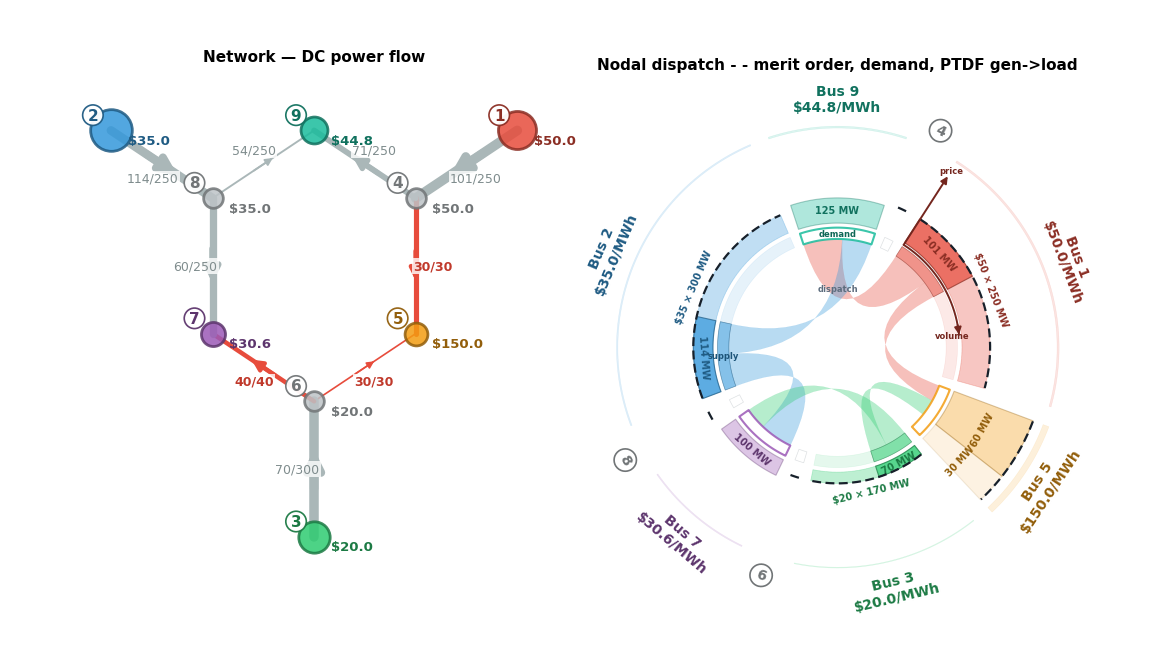

In [5]:
# The two-panel composite of the unified clearing: network DC power flow (left)
# and the nodal dispatch diagram (right). This is the set-up view; the BA split
# and allocation come next.
sup, dem = to_supply_demand(unified, res)
colors = dict(BUS_COLORS)
binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=colors, bus_lmps=res.lmp,
    line_flows={l: res.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, served_demand(res, dem)),
    clearing_price=res.energy_price,
    demand_segments=shed_segments(res, dem),
    lmp_line=True, annotate_roles=True, axis_key=True,
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,
    title_right='Nodal dispatch - - merit order, demand, PTDF gen->load',
)
plt.show()

**Read it:** with `line_4` (6–7) limited to 40 MW, the binding internal limit
splits the LMPs — the bus-7 load behind the constraint prices up to ~\$37 while the
cheap bus-3 pocket (\$20) stays low. The congestion term is exactly
$\sum_m SF_{n,m}\,\mu_m$; set `LINE_RATINGS = {}` and re-run to collapse every bus
back to a single energy price.

## 2. Two balancing authorities on the shared network

In [6]:
## -- EDIT -- the two balancing authorities, and the lines each manages.
BA_DEFS = {
    'BA-1': ['2', '8', '7', '6', '3'],   # cheap fleet (bus 3 $20, bus 2 $35); load at 7 -> exporter
    'BA-2': ['1', '9', '4', '5'],         # only the bus-1 unit ($50); loads at 5 and 9 -> importer
}
BA_LINES = {  # any line may be listed under either BA; a line under neither is unassigned (grey, rent split 50/50)
    'BA-1': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],   # line_2 = tie 5-6
    'BA-2': ['line_0', 'line_1', 'line_7', 'line_8'],             # line_7 = tie 8-9
}
BA_COLORS = {'BA-1': '#993AFF', 'BA-2': '#2471A3'}
# ---------------------------------------------------------------------------
pt = shift_factors()
fp = fpmod.make(pt, BA_DEFS, BA_COLORS, manage=BA_LINES, tie_label='tie')

# Notebook aliases so the methodology/figure cells below read naturally.
ba_of = fp.fp_of
LINE_BA = fp.line_assign
AREAS = fp.areas
ties = fp.ties
LOADS_ALL = dict(LOADS)
line_kind = lambda _pt, l: fp.line_kind(_pt, l)
ba_line_colors = lambda _pt: fp.line_colors(_pt)
BA_GROUPS = fp.groups(pt)

print('BA-1 buses:', BA_DEFS['BA-1'], '| manages:', [l for l in pt.lines if LINE_BA[l] == 'BA-1'])
print('BA-2 buses:', BA_DEFS['BA-2'], '| manages:', [l for l in pt.lines if LINE_BA[l] == 'BA-2'])
print('tie lines:', ties, '| unassigned:', [l for l in pt.lines if LINE_BA[l] is None] or 'none')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


BA-1 buses:

['2', '8', '7', '6', '3']

| manages:

['line_2', 'line_3', 'line_4', 'line_5', 'line_6']

...

['line_0', 'line_1', 'line_7', 'line_8']

tie lines:

['line_2', 'line_7']

| unassigned:

none

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


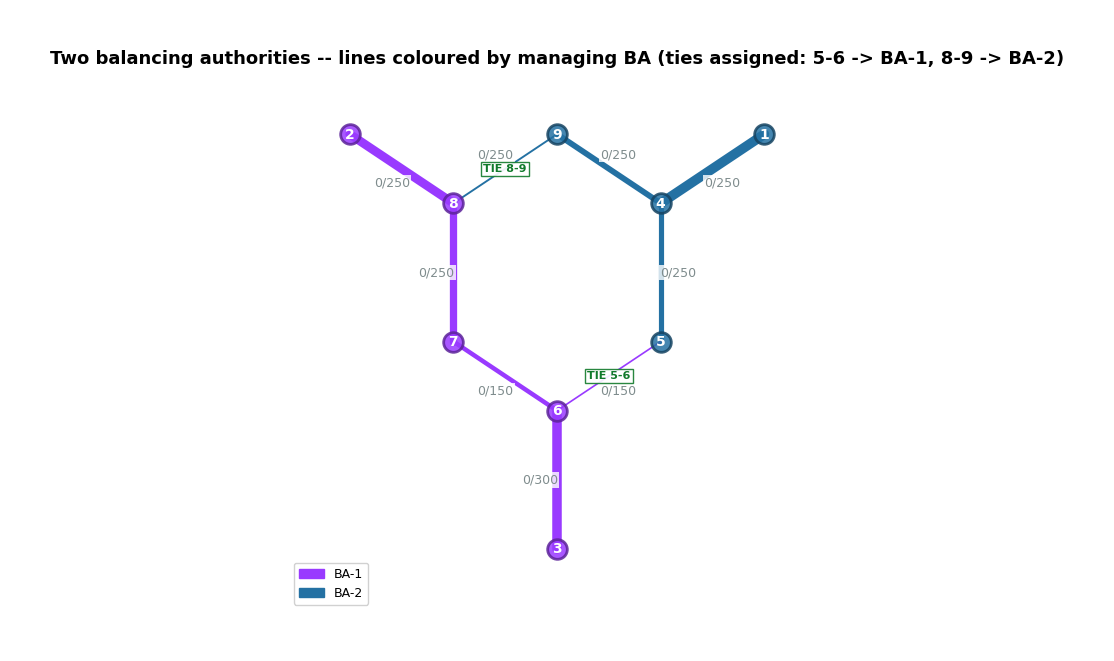

In [7]:
# Map of the two BAs and the interconnectors (buses coloured by BA).
ba_bus_colors = {b: BA_COLORS[ba_of(b)] for b in pt.buses}
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=ba_bus_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=ba_line_colors(pt),   # lines coloured by the BA that manages them (LINE_BA); unassigned grey
    title='Two balancing authorities -- lines coloured by managing BA (ties assigned: 5-6 -> BA-1, 8-9 -> BA-2)',
)
for l in ties:
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    ax.text((x0+x1)/2, (y0+y1)/2, f'TIE {b0}-{b1}', fontsize=8, fontweight='bold',
            color='#117A2B', ha='center', va='center',
            bbox=dict(fc='white', ec='#117A2B', alpha=0.9, pad=1.5), zorder=7)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=BA_COLORS[ba], label=ba) for ba in BA_DEFS],
          loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

### Two allocation rules

The same rent $R$ from eq.&nbsp;(6), now split between the two BAs. First the per-BA
ledger, then the border term, then the two methods — each as an equation with a
plain-language reading.

**Per-BA ledger.** For BA $a$ with buses $\mathcal N_a$:

$$G_a=\sum_{n\in\mathcal N_a}\lambda_n g_n,\qquad
  L_a=\sum_{n\in\mathcal N_a}\lambda_n d_n,\qquad
  N_a=L_a-G_a,\qquad \sum_a N_a=R. \qquad (7)$$

*In words.* $G_a$ is what the BA's **generators are paid**, $L_a$ what its **loads pay**, and
$N_a$ its **net payment into the congestion pool**. The two BAs' net payments sum to the whole
rent $R$ — congestion is a transfer from net-paying areas to net-receiving ones. Buses
outside both BAs — a **non-market area** — settle the same way and join the
sum: they pay or are paid at LMP but are never *allocated* rent, and the
ledgers grow a matching column. (`ba_settlement`: `gen_rev`, `load_pay`,
`net_into_pool`; areas come from `AREAS` in the Section-3 config.)

**Rent by line assignment.** Each line is **assigned** to at most one BA — a
configurable choice (the `BA_LINES` lists), not a consequence of the bus partition.
$\mathcal M_a$ is the set of lines assigned to BA $a$ and $\mathcal M_{\emptyset}$
the unassigned remainder. By default a line with both ends in BA $a$ is assigned
to it; here the two ties are also assigned — `line_2` to BA-1, `line_7` to BA-2 —
so $\mathcal M_{\emptyset}$ is empty:

$$R=R^{\emptyset}+\sum_a R_a,\qquad
  R_a=\!\!\sum_{m\,\in\,\mathcal M_a}\!\!|\mu_m F_m|,\qquad
  R^{\emptyset}=\!\!\sum_{m\,\in\,\mathcal M_{\emptyset}}\!\!|\mu_m F_m|. \qquad (8)$$

*In words.* Split the total rent by **which BA manages the binding line**. A line assigned to
BA $a$ feeds $R_a$; rent on lines assigned to neither BA pools in $R^{\emptyset}$.
(`line_rent_table`, `BA_LINES`.)

**Cross-border separation rent.** A **tie** is a line whose ends sit in different
BAs — the set $\mathcal M^{\mathrm{tie}}$. This is *topological* (fixed by the bus
partition), independent of the management assignment above: assigning `line_2` to
BA-1 does not stop it crossing the border. On each tie $m$ from $b_0$ to $b_1$
carrying flow $F_m$, price the cross-border gap from its **causes** — the binding
line constraints, through their shift factors — not by reading the raw nodal gap
off the solution:

$$\Delta\lambda^{\mathrm{cong}}_m=\!\!\sum_{m'\in\mathcal M_{\mathrm{act}}}\!\!\big(SF_{b_1,m'}-SF_{b_0,m'}\big)\,\mu_{m'},\qquad
\tau=\sum_{m\,\in\,\mathcal M^{\mathrm{tie}}}\big|\,\Delta\lambda^{\mathrm{cong}}_m\,F_m\,\big|. \qquad (9)$$

*In words.* Each binding line's shadow price reaches the tie's two ends with
different leverage; the shift-factor difference times $\mu_{m'}$ adds up exactly
the price gap **that line congestion creates** across the border, and $\tau$ values
the crossing power at that gap — what the importing BA's load pays *above* what
the exporting BA's generation receives, for the energy that crosses. By eq. (5)
this *equals* the raw gap $\lambda_{b_1}-\lambda_{b_0}$ whenever line limits are
the only binding constraints (as here), but the two part ways in Section 4, where
a transfer constraint separates prices for a different reason with its own revenue
stream — built this way, $\tau$ collects only the congestion-caused piece, every
dollar of it traceable to a binding line of eq. (8). It is also how the congestion
component of a nodal price is formed in practice: shift factors times constraint
shadow prices, never a price difference read between two nodes. This is the piece
of the rent the border itself creates, and the piece Method&nbsp;2 reassigns.
(`border_separation`: `dlam_cong`, `sep_rent`.)

---

**Method&nbsp;1 — the constraint's home BA keeps its full rent.**

$$A^{(1)}_a=R_a+\tfrac12\,R^{\emptyset}. \qquad (10)$$

*In words.* Each BA banks the **full** $\mu_m\!\cdot\!F_m$ rent of every line **assigned
to it**; rent on unassigned lines is split 50/50 (none arise under the default assignment
here). An **internal** constraint's rent stays home **even when that constraint separated
prices in the other BA** — the rent follows the wire's assignment, not the price impact.
This is the full constraint revenue accruing only to the managing BA's settlement.

**Method&nbsp;2 — rebate the cross-border separation to the load that over-paid.**
Let $h=\operatorname*{arg\,max}_a N_a$ be the **net-payer** BA and $f$ the other:

$$A^{(2)}_h=A^{(1)}_h+\tau,\qquad A^{(2)}_f=A^{(1)}_f-\tau. \qquad (11)$$

*In words.* Start from Method&nbsp;1, then **move the border rent $\tau$** from the funding BA $f$
to the net-payer BA $h$ — the side whose loads over-paid because the constraint pulled their
price away from the generation serving them. This rebates the cross-border
generation$\to$load transfer to that BA (congestion-revenue rights to its consumers). Total
rent is conserved: $A^{(2)}$ still sums to $R$. The choice of $\tau$ and of the recipient is a
**v1 rule, written explicitly so it can be refined** (e.g. later split $\tau$ between
importer-load and exporter-gen).

---

**Two readings of each BA's outcome** (the bottom row of each ledger, built in `revenue_table` — one table per method):

$$\underbrace{P^{(k)}_a=A^{(k)}_a-N_a}_{\text{area net position}},
  \qquad\qquad
  \underbrace{\tilde L^{(k)}_a=L_a-A^{(k)}_a}_{\text{load cost net of CRR}}. \qquad (12)$$

*In words.* $P^{(k)}_a=0$ means method $k$ makes BA $a$ **whole** — its allocated rent exactly
offsets its net payment into the pool. $\tilde L^{(k)}_a$ is the BA's load bill **after** its
allocated rent is rebated to its own consumers as congestion-revenue rights — the number a
load-serving entity ultimately feels. In the ledgers below each BA's **consumers and
generators sit side by side** (cash out negative, cash in positive — the same
conventions as the autarky-vs-unified comparison closing this section), and the
bottom row carries both readings at once: the **Area net** column is $P^{(k)}_a$
and the **Consumer** column is $-\tilde L^{(k)}_a$. Comparing that row across the
Method&nbsp;1 and Method&nbsp;2 tables is the whole point of the exercise.

In [8]:
# Methodology — implemented in revenue_allocation.py (edit there to refine the
# allocation rule); bound here to this notebook's footprint `fp`.
ba_settlement            = lambda res, loads: ra.ba_settlement(fp, res, loads)
line_rent_table          = lambda res, pt: ra.line_rent_table(fp, res, pt)
border_separation        = lambda res, pt: ra.border_separation(fp, res, pt)
allocate_congestion_rent = lambda res, pt, loads, **kw: ra.allocate_congestion_rent(fp, res, pt, loads, **kw)
compare_methods          = lambda res, pt, loads: ra.compare_methods(fp, res, pt, loads)
print('methodology bound: ba_settlement, line_rent_table, border_separation, '
      'allocate_congestion_rent, compare_methods  (see revenue_allocation.py)')

methodology bound: ba_settlement, line_rent_table, border_separation, allocate_congestion_rent, compare_methods  (see revenue_allocation.py)

In [9]:
# Presentation helpers — figures from wscc9_figures.py, ledgers from
# revenue_allocation.py; bound to fp.
from revenue_allocation import settlement_by_bus, capacity_value_by_line
revenue_table = lambda res, pt, loads: ra.revenue_table(fp, res, pt, loads)

def example_figure(net, pt, engine, res, **kw):
    return figs.footprint_figure(net, pt, fp, engine, res, **kw)

print('presentation bound: example_figure, revenue_table, settlement_by_bus, capacity_value_by_line')

presentation bound: example_figure, revenue_table, settlement_by_bus, capacity_value_by_line

### The scenario — an *internal* constraint, separation in the *other* BA

Congest a line that
lives entirely inside BA-1 (the exporter). The binding limit both isolates a
price pocket at the BA-1 load behind it **and**, through the shift factors, pulls
**BA-2's prices away from the system price** as generation is redispatched across
the border. As a result, prices separate on both sides even though the binding line is
internal to BA-1 and no tie is overloaded.

- **Method 1** credits all of the rent to **BA-1** (the binding line is assigned
  to it), regardless of where the price separation is felt.
- **Method 2** rebates the cross-border separation rent $\tau$ to whichever BA is
  the **net payer** into the congestion pool — the side whose load over-paid for
  the separation — funded by the other BA.

Whether the net-payer turns out to be BA-1 or BA-2 depends on the constraint; the
cells below report it from the actual settlement rather than assuming it. Edit
`SCN_B` to choose which internal BA-1 line binds and how hard.

In [10]:
# -- EDIT -- the scenario: congest a line INTERNAL to BA-1 (the exporter)
SCN_B = {'line_4': 40.0}          # 6-7, internal to BA-1; throttles the cheap bus-3 delivery
# -------------------------------------------------------------------------
net = build_network(SCN_B); pt = compute_ptdf(net, slack_bus='1')
res = solve_engine_dispatch(pt, make_engine('UNIFIED', buses=pt.buses))

print('LMP by bus:', {b: round(res.lmp[b], 1) for b in pt.buses})
print('  BA-1 LMPs:', {b: round(res.lmp[b], 1) for b in BA_DEFS['BA-1']})
print('  BA-2 LMPs:', {b: round(res.lmp[b], 1) for b in BA_DEFS['BA-2']})
print('binding lines:', {l: round(res.line_dual[l], 1) for l in pt.lines if abs(res.line_dual[l]) > 1e-3},
      '(managed by:', {l: LINE_BA[l] for l in pt.lines if abs(res.line_dual[l]) > 1e-3}, ')')

# Line-level diagnostic: where the rent sits, and the border separation behind Method 2.
_, summ, lr, sep = compare_methods(res, pt, LOADS_ALL)
print('\nper-line congestion rent (binding lines):')
display(lr[lr.rent > 1e-3].round({'rent': 1}))
print('cross-border separation by tie  (note: a tie carries separation even though it does NOT bind):')
display(sep.round({'sep_rent': 1}))
print(f"total rent R = {summ['R']:.1f}  |  BA-1 lines = {summ['R_own']['BA-1']:.1f}  |  "
      f"BA-2 lines = {summ['R_own']['BA-2']:.1f}  |  unassigned = {summ['R_unassigned']:.1f}")
print(f"cross-border separation tau = {summ['tau']:.1f}  ->  net-payer (hedged) BA = {summ['hedged_ba']} "
      f"(Method 2 moves tau from {summ['funding_ba']} to {summ['hedged_ba']})")
print('BA-level congestion-revenue accounting (the ledgers) is in the next cell -- Method 1 vs Method 2.')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


LMP by bus:

{'1': np.float64(27.7), '2': np.float64(35.0), '3': np.float64(20.0), '4': np.float64(27.7), '5': np.float64(25.0), '6': np.float64(20.0), '7': np.float64(37.1), '8': np.float64(35.0), '9': np.float64(30.2)}

  BA-1 LMPs:

{'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(37.1), '6': np.float64(20.0), '3': np.float64(20.0)}

...

cross-border separation by tie  (note: a tie carries separation even though it does NOT bind):

,flow,dlam,dlam_cong,dlam_xfer,sep_rent,importing,exporting
line,,,,,,,
line_2,-98.9,-5.02,-5.02,-0.0,496.6,BA-2,BA-1
line_7,116.1,-4.75,-4.75,0.0,551.8,BA-2,BA-1


total rent R = 804.1  |  BA-1 lines = 804.1  |  BA-2 lines = 0.0  |  unassigned = 0.0

cross-border separation tau = 1048.4  ->  net-payer (hedged) BA = BA-2 (Method 2 moves tau from BA-1 to BA-2)

BA-level congestion-revenue accounting (the ledgers) is in the next cell -- Method 1 vs Method 2.

**Reading the scenario.** The binding constraint is inside BA-1, so under
**Method 1** BA-1 banks the entire congestion rent simply because its wires host
the limit. **Method 2** instead rebates the cross-border separation $\tau$ to the
BA whose participants were the net payers for that separation, so each BA ends up
holding rent commensurate with the price gap *its own meters* bore rather than the
gap its wires happened to host. The `TOTAL` column is identical under both methods
— the rent is only **reallocated**, never created or destroyed. (The contrast is
sharpest when the constraint's home BA and the net-paying BA differ; tune `SCN_B`
to explore that.)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


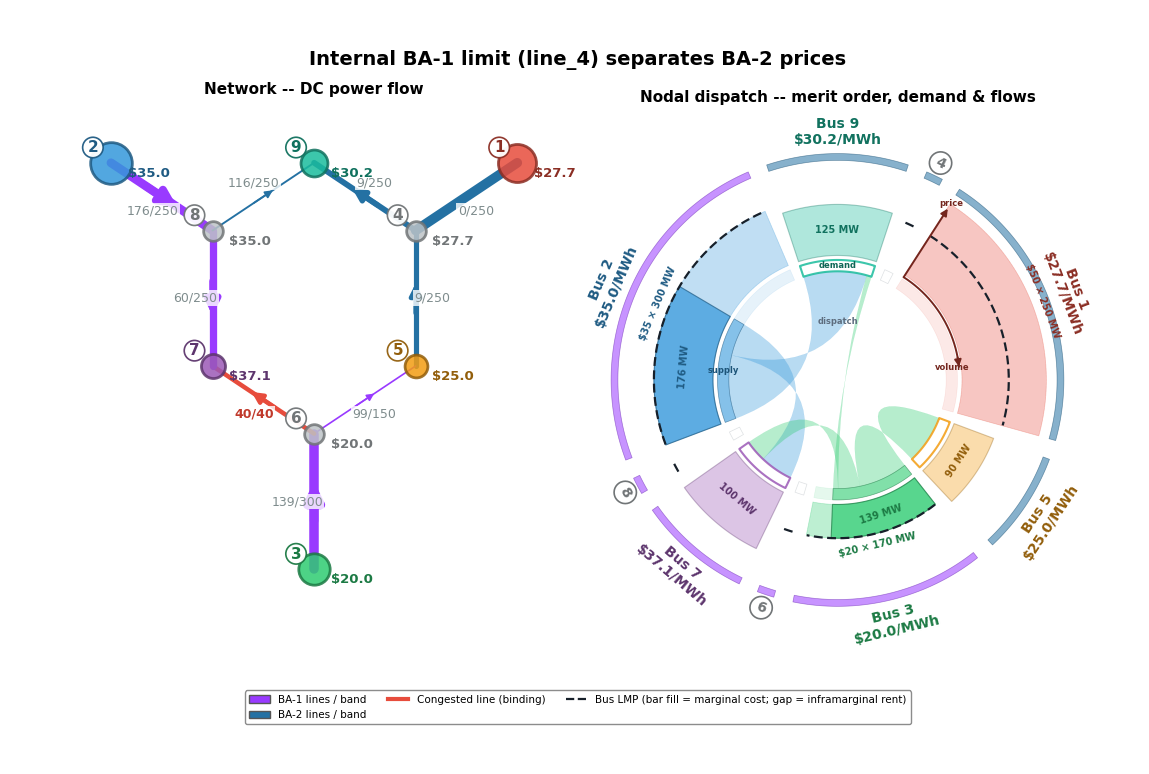

Rent on the internal BA-1 line, R = $804/h; Method 1 banks it in BA-1 (its wires host the limit), Method 2 moves tau = $1048/h to net-payer BA-2.

Compare the bottom 'Net position' row: Area net = A - N (0 => made whole); the Consumer

column is the load bill net of CRR, as a cash position (negative = cash out).

Method 1 -- each BA keeps the rent on its assigned lines:

BA-1                        BA-2                     TOTAL
                                     Consumer Generator Area net Consumer Generator Area net       
Energy settlement  (lmp x q)          -3712.6    8941.0   5228.4  -6032.5       0.0  -6032.5 -804.1
Congestion rent allocated  (A)          804.1              804.1      0.0                0.0  804.1
Net position  (Area net: 0 => whole)  -2908.5    8941.0   6032.5  -6032.5       0.0  -6032.5    0.0

Method 2 -- rebate cross-border separation tau to the net-payer BA:

BA-1                        BA-2                     TOTAL
                                     Consumer Generator Area net Consumer Generator Area net       
Energy settlement  (lmp x q)          -3712.6    8941.0   5228.4  -6032.5       0.0  -6032.5 -804.1
Congestion rent allocated  (A)         -244.3             -244.3   1048.4             1048.4  804.1
Net position  (Area net: 0 => whole)  -3956.9    8941.0   4984.1  -4984.1       0.0  -4984.1    0.0

In [11]:
# The scenario -- composite figure + homework-style congestion-revenue tables.
net = build_network(SCN_B); pt = compute_ptdf(net, slack_bus='1')
uni = make_engine('UNIFIED', buses=pt.buses); res = solve_engine_dispatch(pt, uni)
example_figure(net, pt, uni, res,
               suptitle='Internal BA-1 limit (line_4) separates BA-2 prices')
plt.show()
rtbl1, rtbl2, summ = revenue_table(res, pt, LOADS_ALL)
print(f"Rent on the internal BA-1 line, R = ${summ['R']:.0f}/h; Method 1 banks it "
      f"in BA-1 (its wires host the limit), Method 2 moves tau = ${summ['tau']:.0f}/h to "
      f"net-payer {summ['hedged_ba']}.")
print("Compare the bottom 'Net position' row: Area net = A - N (0 => made whole); the Consumer")
print("column is the load bill net of CRR, as a cash position (negative = cash out).")
print("Method 1 -- each BA keeps the rent on its assigned lines:")
display(rtbl1)
print("Method 2 -- rebate cross-border separation tau to the net-payer BA:")
display(rtbl2)

### Unified vs independent operation — the two-engine counterfactual

The cross-border separation exists only because a **single co-optimised clearing**
prices every bus against *all* constraints at once. The counterfactual is
**independent operation**: each BA runs as its own *independent engine* on the
same full 9-bus network — serving its own load from its own generators and
enforcing **only the lines assigned to it** (`LINE_BA`: its internal lines plus
its assigned tie), with every other line left unconstrained (a nodal DC-OPF per
BA, not a copperplate). No interchange is scheduled.

Two things surface:

1. On the **base network** each BA clears at its own price.
2. On the **scenario network**, BA-1's internal `line_4` limit splits prices
   *within* BA-1 and, through the shift factors, moves BA-2's prices too. Under
   the **unified clearing** the same constraint is co-optimised against the border,
   and the resulting cross-border price separation is the congestion rent that then
   has to be allocated.

In [12]:
# Independent operation: each BA as its own engine on the full network
# (revenue_allocation.independent_clear), bound to fp.
independent_clear = lambda rat, shed_price=None: ra.independent_clear(fp, rat, shed_price=shed_price)

# (a) Base network -- both BAs self-serve; the price gap is what motivates trade.
_, base = independent_clear({})
print('independent prices on the BASE network:',
      {ba: (f"${base[ba].energy_price:.0f}" if base[ba] else 'INFEASIBLE') for ba in BA_DEFS})

# (b) Scenario network -- the internal BA-1 limit as the counterfactual stress.
ptB, indep = independent_clear(SCN_B)
resU = solve_engine_dispatch(ptB, make_engine('UNIFIED', buses=ptB.buses))
cmp = pd.DataFrame({b: {
    'BA': ba_of(b),
    'independent LMP': (round(indep[ba_of(b)].lmp[b], 1) if indep[ba_of(b)] else float('nan')),
    'unified LMP (scenario)': round(resU.lmp[b], 1),
} for b in ptB.buses}).T
display(cmp)
for ba in BA_DEFS:
    if indep[ba] is None:
        print(f'{ba} is INFEASIBLE on its own: with the line_4 limit and only its own '
              f'generation it cannot serve its load -- it depends on imports across the '
              f'border. That dependence is what the unified clearing prices, and what the '
              f'congestion-revenue allocation then divides.')
    else:
        gap = max(indep[ba].lmp[b] for b in BA_DEFS[ba]) - min(indep[ba].lmp[b] for b in BA_DEFS[ba])
        print(f'{ba} independent: clears feasibly, internal price spread ${gap:.1f}/MWh.')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


independent prices on the BASE network:

{'BA-1': '$20', 'BA-2': '$50'}

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


,BA,independent LMP,unified LMP (scenario)
1,BA-2,50.0,27.7
2,BA-1,35.0,35.0
3,BA-1,20.0,20.0
4,BA-2,50.0,27.7
5,BA-2,50.0,25.0
6,BA-1,20.0,20.0
7,BA-1,37.1,37.1
8,BA-1,35.0,35.0
9,BA-2,50.0,30.2


BA-1 independent: clears feasibly, internal price spread $17.1/MWh.

BA-2 independent: clears feasibly, internal price spread $0.0/MWh.

### The two-BA dispatch, per BA (other BA greyed)

The independent two-BA dispatch drawn as a combined network + nodal-merit chart. The other BA's nodes greyed out. Because each BA
clears only its own footprint, its chart shows only its own generation, load, and
within-BA chords. 

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


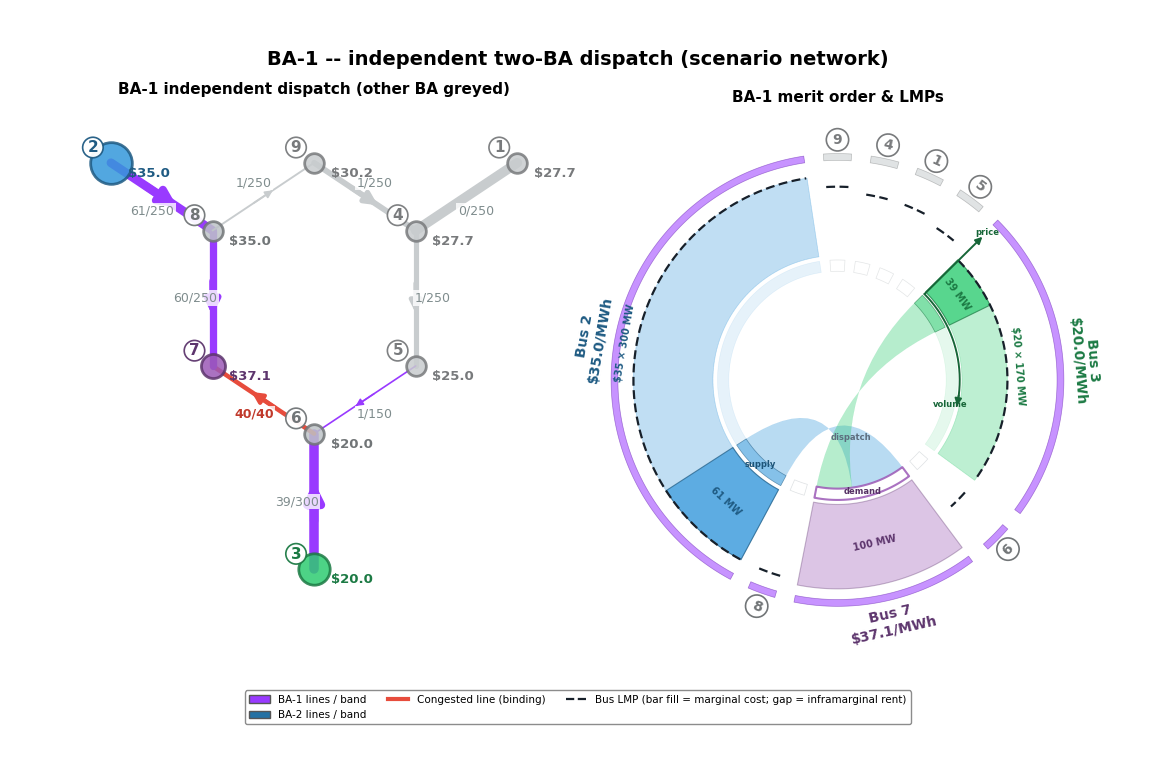

BA-1: energy $28/MWh; own-bus LMPs {'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(37.1), '6': np.float64(20.0), '3': np.float64(20.0)}

BA-1 -- settlement by node (independent clearing):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
2,35.0,60.6,2119.8,0.0,0.0
8,35.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
6,20.0,0.0,0.0,0.0,0.0
3,20.0,39.4,788.7,0.0,0.0
SUBTOTAL,,100.0,2908.5,100.0,3712.6


BA-1 -- marginal value of its assigned lines (shadow price x flow):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_2,5,6,0.6,150.0,False,0.0,0.0
line_3,3,6,39.4,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-60.6,250.0,False,0.0,0.0
TOTAL,,,,,,,804.1


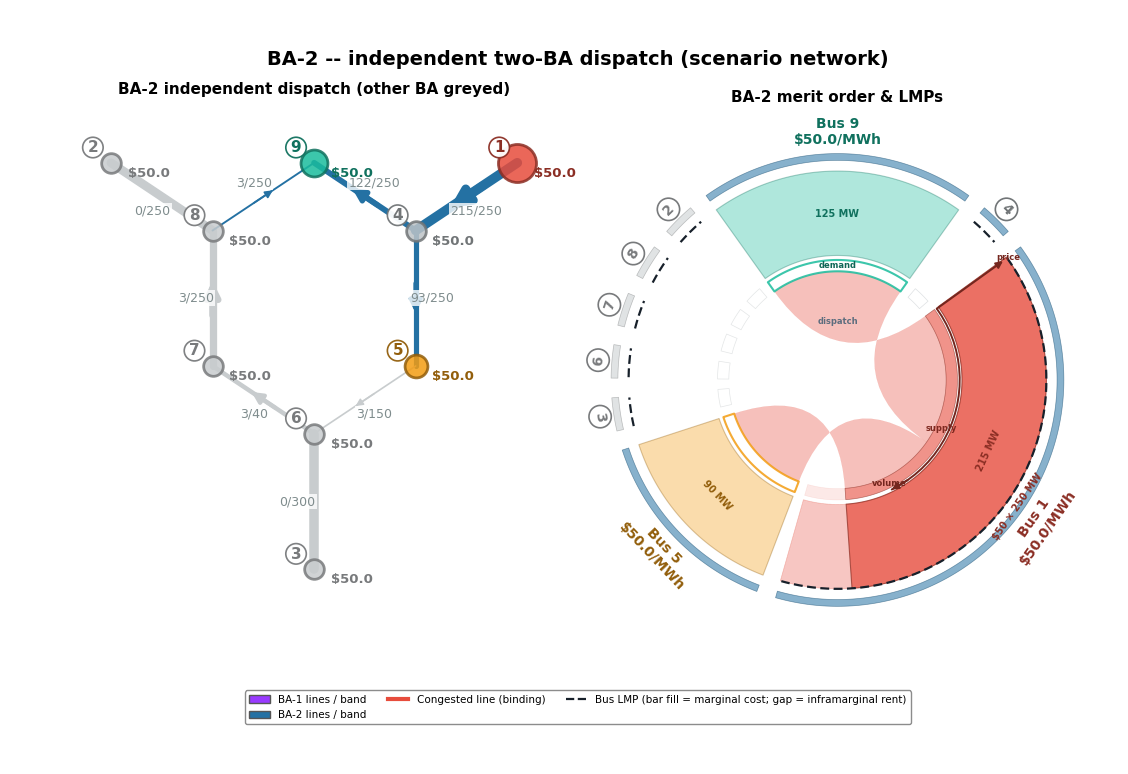

BA-2: energy $50/MWh; own-bus LMPs {'1': np.float64(50.0), '9': np.float64(50.0), '4': np.float64(50.0), '5': np.float64(50.0)}

BA-2 -- settlement by node (independent clearing):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,50.0,215.0,10750.0,0.0,0.0
9,50.0,0.0,0.0,125.0,6250.0
4,50.0,0.0,0.0,0.0,0.0
5,50.0,0.0,0.0,90.0,4500.0
SUBTOTAL,,215.0,10750.0,215.0,10750.0


BA-2 -- marginal value of its assigned lines (shadow price x flow):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,215.0,250.0,False,0.0,0.0
line_1,4,5,93.4,250.0,False,0.0,0.0
line_7,8,9,3.4,250.0,False,0.0,0.0
line_8,9,4,-121.6,250.0,False,0.0,0.0
TOTAL,,,,,,,0.0


In [13]:
# Per-BA composite of the INDEPENDENT two-BA dispatch (scenario network),
# with the other BA's nodes greyed out. Each BA clears only its own footprint,
# so its chart carries only its own generation, load, and within-BA chords.
netB = build_network(SCN_B); ptB = compute_ptdf(netB, slack_bus='1')
for ba in BA_DEFS:
    act = [l for l in ptB.lines if LINE_BA.get(l) == ba]
    eng = make_engine(ba, BA_DEFS[ba], activated=act)
    r = solve_engine_dispatch(ptB, eng)
    other = [b for b in ptB.buses if ba_of(b) != ba]
    example_figure(netB, ptB, eng, r, dim_buses=other,
                   title_left=f'{ba} independent dispatch (other BA greyed)',
                   title_right=f'{ba} merit order & LMPs',
                   suptitle=f'{ba} -- independent two-BA dispatch (scenario network)')
    plt.show()
    print(f"{ba}: energy ${r.energy_price:.0f}/MWh; own-bus LMPs "
          f"{ {b: round(r.lmp[b], 1) for b in BA_DEFS[ba]} }")
    # Bus-level and constraint-level accounting for this BA's independent clearing
    # (the same tables as the unified clearing in Section 2, restricted to the BA).
    print(f'{ba} -- settlement by node (independent clearing):')
    display(settlement_by_bus(r, BA_DEFS[ba], LOADS_ALL))
    print(f'{ba} -- marginal value of its assigned lines (shadow price x flow):')
    display(capacity_value_by_line(r, ptB, act))

### Autarky vs unified -- the gains from trade and who captures them

Each BA's **consumer** and **generator** position under
**autarky** (independent operation -- each BA serves its own load on its own internal
limits) versus the **unified** clearing, with the congestion rent rebated to consumers
as congestion-revenue rights (CRR). 

Conventions: consumer payments are negative (cash out), generator revenue positive (cash
in); a BA's generator **position** is producer surplus (revenue minus production cost),
and its **final** consumer position is the load bill net of the CRR rebate. **Autarky also
rebates each BA's own internal congestion rent to its own consumers** -- the same CRR
treatment as the unified case -- so the comparison is like-for-like and the change versus
autarky isolates the gains from trade plus any cross-border reallocation, which drives the
Pareto check.

*Note on this fleet:* with one unit per bus each generator sets its own bus price, so
producer surplus is ~0 everywhere and the entire price wedge is congestion rent -- all
the distributional action sits on the consumer / CRR side. That degeneracy lifts once the
fleet becomes a real supply mix (a baseload block plus a sloped mid-merit/peaking ramp),
at which point the generator columns carry genuine inframarginal rent and the same ledger
keeps working unchanged. (This is a planned future enhancement.)

In [14]:
# Autarky (independent) vs unified, homework-style -- one table per allocation
# method (autarky_vs_unified lives in revenue_allocation.py; bound to fp).
netB = build_network(SCN_B); ptB = compute_ptdf(netB, slack_bus='1')
resU = solve_engine_dispatch(ptB, make_engine('UNIFIED', buses=ptB.buses))
_, indepB = independent_clear(SCN_B)
alloc, summ, _, _ = allocate_congestion_rent(resU, ptB, LOADS_ALL)
COST = ra.cost_by_bus(GEN_FLEET)                          # bus -> marginal cost

_agg = lambda result, area: ra._agg(fp, result, area, LOADS_ALL, COST)
autarky_vs_unified = lambda method: ra.autarky_vs_unified(fp, method, alloc, indepB, resU, LOADS_ALL, COST)

pc_aut = sum(_agg(indepB[ba], ba)[2] for ba in AREAS)
pc_uni = sum(_agg(resU, ba)[2] for ba in AREAS)
print(f"System production cost: autarky ${pc_aut:,.0f}/h  ->  unified ${pc_uni:,.0f}/h  "
      f"(gains from trade ${pc_aut - pc_uni:,.0f}/h);  congestion rent R = ${summ['R']:.0f}/h.")
print("Autarky rebates each BA's own internal congestion rent to its own consumers, so "
      "Delta-vs-autarky isolates the gains from trade and the cross-border reallocation.")
print("\nMethod 1 -- each BA keeps the rent on its assigned lines:")
display(autarky_vs_unified(1))
print("Method 2 -- rebate the cross-border separation tau to the net-payer BA:")
display(autarky_vs_unified(2))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


System production cost: autarky $13,659/h  ->  unified $8,941/h  (gains from trade $4,717/h);  congestion rent R = $804/h.

Autarky rebates each BA's own internal congestion rent to its own consumers, so Delta-vs-autarky isolates the gains from trade and the cross-border reallocation.


Method 1 -- each BA keeps the rent on its assigned lines:

BA-1               BA-2          
                                   Consumer Generator Consumer Generator
Autarky: payment / revenue          -3712.6    2908.5 -10750.0   10750.0
Autarky: production cost                      -2908.5           -10750.0
Autarky: own congestion rent (CRR)    804.1                0.0          
Autarky: position                   -2908.5       0.0 -10750.0       0.0
Unified: payment / revenue          -3712.6    8941.0  -6032.5       0.0
Unified: production cost                      -8941.0               -0.0
Congestion rent (CRR)                 804.1                0.0          
Final position                      -2908.5       0.0  -6032.5       0.0
Delta vs autarky                        0.0       0.0   4717.5       0.0
Pareto (Delta >= 0)                     yes       yes      yes       yes

Method 2 -- rebate the cross-border separation tau to the net-payer BA:

BA-1               BA-2          
                                   Consumer Generator Consumer Generator
Autarky: payment / revenue          -3712.6    2908.5 -10750.0   10750.0
Autarky: production cost                      -2908.5           -10750.0
Autarky: own congestion rent (CRR)    804.1                0.0          
Autarky: position                   -2908.5       0.0 -10750.0       0.0
Unified: payment / revenue          -3712.6    8941.0  -6032.5       0.0
Unified: production cost                      -8941.0               -0.0
Congestion rent (CRR)                -244.3             1048.4          
Final position                      -3956.9       0.0  -4984.1       0.0
Delta vs autarky                    -1048.4       0.0   5765.9       0.0
Pareto (Delta >= 0)                      no       yes      yes       yes

## 3. Optimized transfers

Transfers between balancing authority areas in the market footprint are
optimized. The market enforces a **scheduling limit** on the net interchange
between the footprints: in EDAM, a transfer is modelled as a matching
export/import pair between two balancing authorities, each BAA's **net
transfer** enters its own power balance, and the scheduling limits are
enforced beside the line limits, under the same generalized network
constraint index. In concept, the transfers are a transport layer on top of
the nodal network layer.

This section adds that transport-layer constraint to the nodal dispatch
developed above: a single limit $\bar E$ on the **net energy interchange** $E$
between BA-1 and BA-2. Its natural ceiling is the **combined rating of the
ties** that physically connect the BAs (`line_2` + `line_7`) — a limit above
that can never bind, because the tie flows already cap the interchange.




### The clearing with a transfer constraint — objective, Lagrangian, prices

**Nomenclature.** The Section-2 symbols carry over with the engine superscript
dropped — the unified clearing is the single engine, exactly as in eq. (6):

| Symbol | Definition |
|---|---|
| $\mathcal N$, $\mathcal R$, $\mathcal M_{\mathrm{act}}$ | buses ($n$), resources ($i$), and activated lines ($m$) — Section 2's sets; every line is activated here |
| $g_i,\ \bar g_i,\ c_i$ | dispatch of resource $i$ (the decision variable), its capacity, and its marginal cost |
| $d_n$ | load at bus $n$ |
| $F_m,\ \bar F_m,\ SF_{n,m}$ | flow on line $m$, its operating limit, and the shift factor of bus $n$ on it |
| $\lambda,\ \lambda_n$ | the energy price (balance dual) and the nodal LMP at bus $n$ (eq. 5) |
| $\mu_m$ | shadow price of line $m$'s activated limit |
| $R$ | congestion rent, $\sum_m\lvert\mu_m F_m\rvert$ (eq. 6) |

New in this section (the BA partition and ties are Section 3's):

| Symbol | Definition |
|---|---|
| $a$, $\mathcal N_a$ | a balancing authority and its bus set (Section 3); $\mathcal N_1$ is BA-1's |
| $\mathcal M^{\mathrm{tie}}$ | the ties — lines whose ends sit in different BAs (Section 3) |
| $\partial\mathcal N_1$ | BA-1's boundary — lines with exactly one end in $\mathcal N_1$ ($=\mathcal M^{\mathrm{tie}}$ when the BAs cover every bus) — eq. (13) |
| $E$ | **net energy interchange** out of BA-1, MW (export positive) — eq. (13) |
| $s_m$ | boundary orientation: $+1$ if line $m$'s from-bus is in $\mathcal N_1$, else $-1$ — eq. (13) |
| $\bar E$ | the **transfer (scheduling) limit** on $\lvert E\rvert$ (`TRANSFER_LIMIT` / `XFER_BIND`) |
| $\mu_T$ | shadow price of the transfer constraint — signed, \$/MWh (`res.interchange_dual`) — eq. (14) |
| $\mathbb 1\{n\in\mathcal N_1\}$ | indicator: $1$ for a BA-1 bus, $0$ otherwise — eq. (16) |
| $R_T$ | **transfer rent**, $\lvert\mu_T\,E\rvert$, \$/h — eq. (17) |
| $\sigma_a$ | (sigma) BA $a$'s **share of the transfer rent**, $\sum_a\sigma_a=1$ — set by the transfer methodology (`allocate_transfer_rent`): T1 the fixed `TRANSFER_SPLIT` shares, T2 all to the net-payer BA |
| $A^T_a$ | transfer rent **allocated** to BA $a$: $A^T_a=\sigma_a\,R_T$, \$/h — eq. (17) |

The dispatch is the Section-2 problem (eqs. (1)–(5); unified single engine,
every line activated) with **one new constraint**. Write $\mathcal N_1$ for
BA-1's bus set and define the **net interchange** out of BA-1:

$$E=\sum_{i:\,\mathrm{bus}(i)\in\mathcal N_1} g_i-\sum_{n\in\mathcal N_1} d_n
   \;=\;\sum_{m\,\in\,\partial\mathcal N_1} s_m\,F_m,
   \qquad s_m=\begin{cases}+1 & \text{line $m$'s from-bus} \in\mathcal N_1,\\ -1 & \text{otherwise.}\end{cases} \qquad (13)$$

*In words.* BA-1's net interchange is whatever its generators produce beyond
its own load (served load, $d_n-u_n$, wherever the Section-2 relaxation sheds).
$\partial\mathcal N_1$ is BA-1's **boundary** — every line with exactly one end
inside $\mathcal N_1$. Lossless DC gives the second equality for free: every
megawatt BA-1 does not consume must leave over its boundary, so the *scheduled*
interchange and the *summed physical boundary flow* are the same number — one
constraint, two readings. Here the two BAs cover every bus, so
$\partial\mathcal N_1=\mathcal M^{\mathrm{tie}}$; with a **non-market area** the
boundary also counts BA-1's lines into it, while $\mathcal M^{\mathrm{tie}}$ —
and the $\tau$ of eq. (9) built on it — stays the BA-to-BA border.

**The problem, restated with the transfer constraint.**

$$\min_{0\le g_i\le\bar g_i}\ \sum_{i\in\mathcal R} c_i\,g_i
  \quad\text{s.t.}\quad
  \sum_{i\in\mathcal R} g_i=\sum_{n\in\mathcal N} d_n\ \ [\lambda],\qquad
  -\bar F_m\le F_m\le\bar F_m\ \ [\mu_m]\ \ (m\in\mathcal M_{\mathrm{act}}),\qquad
  -\bar E\le E\le\bar E\ \ [\mu_T]. \qquad (14)$$

*In words.* The objective and the first two constraint families are exactly
Section 2's (1)–(3); the transfer constraint is one more row with its own
(signed) multiplier $\mu_T$ — in EDAM terms, an intertie scheduling limit
enforced beside the line limits under the same generalized constraint index.

**The Lagrangian with the new term.**

$$\mathcal L=\sum_{i\in\mathcal R} c_i\,g_i
  -\lambda\Big(\sum_{i\in\mathcal R} g_i-\sum_{n\in\mathcal N} d_n\Big)
  -\!\!\sum_{m\in\mathcal M_{\mathrm{act}}}\!\!\mu_m\,F_m
  \;-\;\mu_T\,E
  \;+\;\sum_{i\in\mathcal R}\overline\mu_i\,(g_i-\bar g_i)-\sum_{i\in\mathcal R}\underline\mu_i\,g_i. \qquad (15)$$

*In words.* Equation (4) plus **one term**: the transfer multiplier times the
interchange. Complementary slackness works as before — $\mu_T\neq 0$ only when
the schedule sits at $\pm\bar E$.

**Stationarity → per-BA energy prices.** For a generator $i$ at bus $n$,
$\partial E/\partial g_i=\mathbb 1\{n\in\mathcal N_1\}$, so for a marginal unit
the bound multipliers drop and the bus price becomes

$$\lambda_n=\lambda+\sum_{m\in\mathcal M_{\mathrm{act}}}SF_{n,m}\,\mu_m
   +\mathbb 1\{n\in\mathcal N_1\}\,\mu_T. \qquad (16)$$

*In words.* Every BA-1 bus carries the **same** extra term. With no line
binding, prices are *flat within each BA* and differ *between* the BAs by
$|\mu_T|$: the transfer constraint splits the single energy price $\lambda$
into two BA-level energy prices — exactly the EDAM structure, where each BAA
carries its own power-balance dual linked by the scheduled transfer. (With the
slack bus in BA-2, $\mu_T<0$ when BA-1's export cap binds: the exporter's
prices sit $|\mu_T|$ *below* the importer's.)

**Transfer rent — a second revenue stream.**

$$R_T=\big|\,\mu_T\,E\,\big|,\qquad
  \underbrace{\sum_{n\in\mathcal N}\lambda_n d_n-\sum_{n\in\mathcal N}\lambda_n g_n}_{\text{paid by load}\ -\ \text{paid to generation}}=R+R_T,\qquad
  A^T_a=\sigma_a\,R_T,\quad \sum\nolimits_a\sigma_a=1. \qquad (17)$$

*In words.* The wedge between what load pays and what generation receives now
has two pieces: the line congestion rent $R$ of eq. (6) and the **transfer
rent** $R_T$ collected on the constrained schedule — the border price gap times
the megawatts crossing it. $R_T$ is a **separate revenue stream** from congestion rent; whenever the
constraint binds it is **allocated by a configurable transfer methodology** —
the $\sigma_a$ of the `allocate_transfer_rent` block: **T1** fixed shares
(`TRANSFER_SPLIT`, default 50/50), **T2** the whole $R_T$ to the net-payer BA,
the transfer analogue of Method 2's rebate. The optimization fixes
$R_T$ itself — the constraint and its dual price the schedule — but not who
receives it: the split is a settlement rule chosen outside the dispatch (EDAM
likewise shares transfer revenue equally between the two BAAs), written here so it
can be refined. Methods 1 and 2 still apply to $R$ only, and because eq. (9)
prices $\tau$ through the **line** multipliers, the separation the schedule
creates is settled exactly once — as $R_T$ — and never re-enters the Method-2
rebate. The transfer row is identical in both ledgers.


In [15]:
# -- EDIT -- the transfer (interchange scheduling) limit ---------------------
TIE_CAP = float(sum(pt.s_nom[pt.line_idx[l]] for l in ties))   # combined tie rating: the physical envelope
TRANSFER_LIMIT = TIE_CAP    # Ebar; lower it below TIE_CAP to make the SCHEDULE bind
# -- EDIT -- allocation methodologies for the two revenue streams -------------
CONGESTION_METHODS = [1, 2]                   # congestion rules to tabulate (one ledger each)
TRANSFER_METHODS   = [1, 2]                   # transfer rules: 1 = fixed shares, 2 = net-payer
TRANSFER_SPLIT = {'BA-1': 0.5, 'BA-2': 0.5}   # Method T1's shares sigma_a (EDAM: equal split)
# ----------------------------------------------------------------------------
assert set(TRANSFER_SPLIT) == set(BA_DEFS) and abs(sum(TRANSFER_SPLIT.values()) - 1.0) < 1e-9, \
    'TRANSFER_SPLIT must cover both BAs and sum to 1'
T_NAMES = ra.T_NAMES

# Transfer model — implemented in revenue_allocation.py / wscc9_figures.py; bound to fp.
transfer_rent          = ra.transfer_rent
allocate_transfer_rent = lambda res, loads, t_method: ra.allocate_transfer_rent(fp, res, loads, t_method, TRANSFER_SPLIT)
solve_with_transfer    = lambda ratings, ebar: ra.solve_with_transfer(fp, ratings, ebar, shed_price=SHED_PRICE)
transfer_ledger        = lambda res, p, loads, method, t_method, indep: \
    ra.transfer_ledger(fp, res, p, loads, method, t_method, indep, TRANSFER_SPLIT)

def draw_net_dispatch(ax, res, ebar, engine):
    return figs.draw_net_dispatch(ax, fp, res, ebar, engine, TIE_CAP)

def transfer_figure(n, p, e, r, ebar, suptitle=None):
    return figs.transfer_figure(n, p, fp, e, r, ebar, TIE_CAP, suptitle=suptitle)

print(f'transfer model bound: TIE_CAP = {TIE_CAP:.0f} MW (combined tie rating);  '
      f'TRANSFER_LIMIT = {TRANSFER_LIMIT:.0f} MW')
print('allocation knobs: CONGESTION_METHODS = ' + str(CONGESTION_METHODS)
      + ',  TRANSFER_METHODS = ' + str(TRANSFER_METHODS) + ' (T1 shares: '
      + ' / '.join(f'{ba} {TRANSFER_SPLIT[ba]:.0%}' for ba in BA_DEFS) + ')')

transfer model bound: TIE_CAP = 400 MW (combined tie rating);  TRANSFER_LIMIT = 400 MW

allocation knobs: CONGESTION_METHODS = [1, 2],  TRANSFER_METHODS = [1, 2] (T1 shares: BA-1 50% / BA-2 50%)

*Reading the figures below.* Each figure gains a small **Transfers** inset
in the lower left of the network panel, drawn to the network diagram's own
visual conventions: each BA collapses to one bubble **sized like the network's
bus bubbles** (generation capacity plus load — the BA's total addressable
market) and labelled with its **net surplus**; the connecting line carries the
interchange as a `flow/limit` label, exactly like a line's `flow/rating`, and
its **width is the transfer limit** $\bar E$ relative to the combined tie
rating — a thin line is a tight tie. When the constraint binds the line turns
**red**, the label sits at its limit (`120/120`), and the transfer shadow
price $|\mu_T|$ appears below it as a price label.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


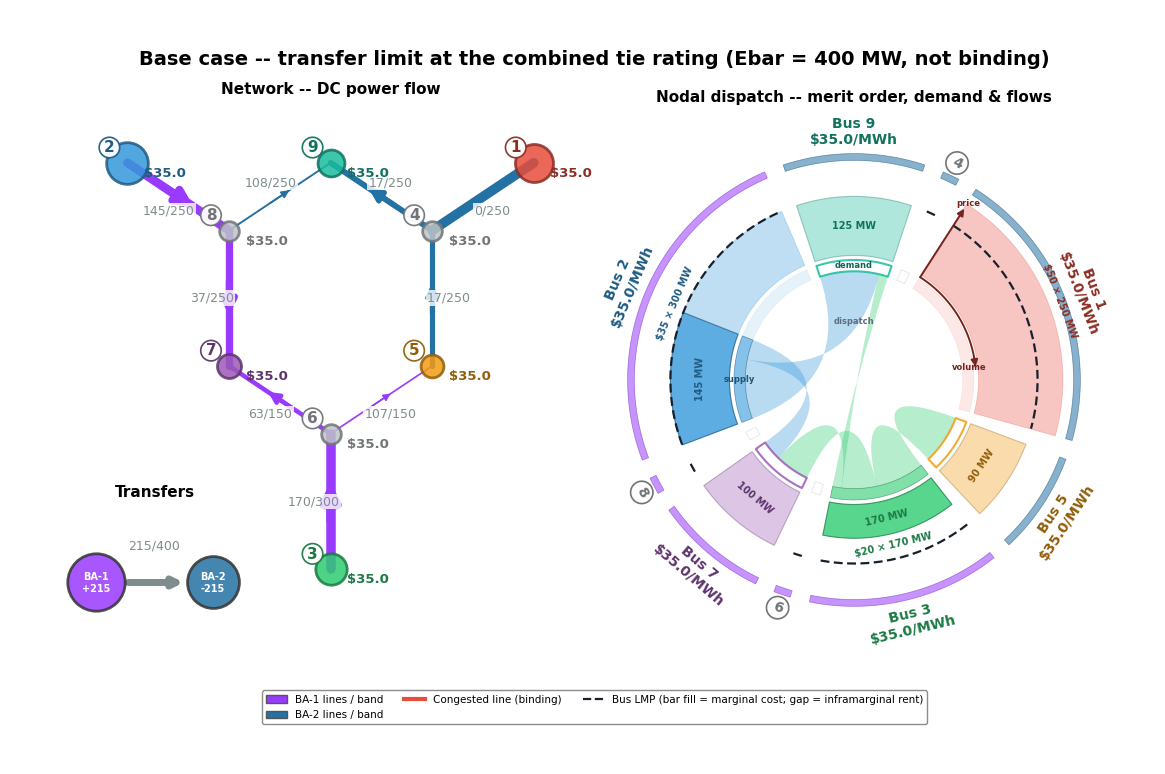

interchange E = 215.0 MW of Ebar = 400 MW  ->  mu_T = 0.00  (not binding)

LMP by bus:

{'1': np.float64(35.0), '2': np.float64(35.0), '3': np.float64(35.0), '4': np.float64(35.0), '5': np.float64(35.0), '6': np.float64(35.0), '7': np.float64(35.0), '8': np.float64(35.0), '9': np.float64(35.0)}

Identical to the unconstrained base clearing: at the physical envelope the transfer constraint adds nothing, and E settles at the 215 MW the network chooses.

In [16]:
# Sample dispatch -- the same base example, transfer limit at the physical envelope.
# At Ebar = TIE_CAP the schedule may use the full combined tie rating, so the
# constraint cannot cut below what the wires already allow -- it is inert.
netT, ptT, engT, resT = solve_with_transfer({}, TRANSFER_LIMIT)
fig = transfer_figure(netT, ptT, engT, resT, TRANSFER_LIMIT,
                      suptitle=f'Base case -- transfer limit at the combined tie rating '
                               f'(Ebar = {TRANSFER_LIMIT:.0f} MW, not binding)')
plt.show()
print(f'interchange E = {resT.interchange_mw:.1f} MW of Ebar = {TRANSFER_LIMIT:.0f} MW'
      f'  ->  mu_T = {resT.interchange_dual:.2f}  (not binding)')
print('LMP by bus:', {bb: round(resT.lmp[bb], 1) for bb in ptT.buses})
print(f'Identical to the unconstrained base clearing: at the physical envelope the '
      f'transfer constraint adds nothing, and E settles at the '
      f'{resT.interchange_mw:.0f} MW the network chooses.')


### The transfer constraint binding

Lower $\bar E$ below the interchange the network wants and the **schedule**
becomes the binding constraint: no wire is at its limit, yet the two BAs'
prices separate by exactly $|\mu_T|$, flat within each footprint (eq. 16). The
wedge that opens between what load pays and what generation receives is the
transfer rent $R_T=|\mu_T E|$ of eq. (17) — a revenue stream the *border itself*
collects, distinct from any line's congestion rent, allocated by the
configured transfer methodology (`TRANSFER_METHODS` — T1 fixed `TRANSFER_SPLIT`
shares, T2 all to the net-payer BA). The ledgers below follow the
autarky-vs-unified format: each BA's consumers and generators side by side,
the **autarky counterfactual on the same ratings**, both revenue streams with
**collected** kept separate from **allocated**, and a **Pareto check** on who
the constrained trade leaves better off. Edit `XFER_BIND` to tighten or relax
the border, and `CONGESTION_METHODS` / `TRANSFER_METHODS` (+ `TRANSFER_SPLIT`,
T1's shares) to change how each stream is allocated.


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


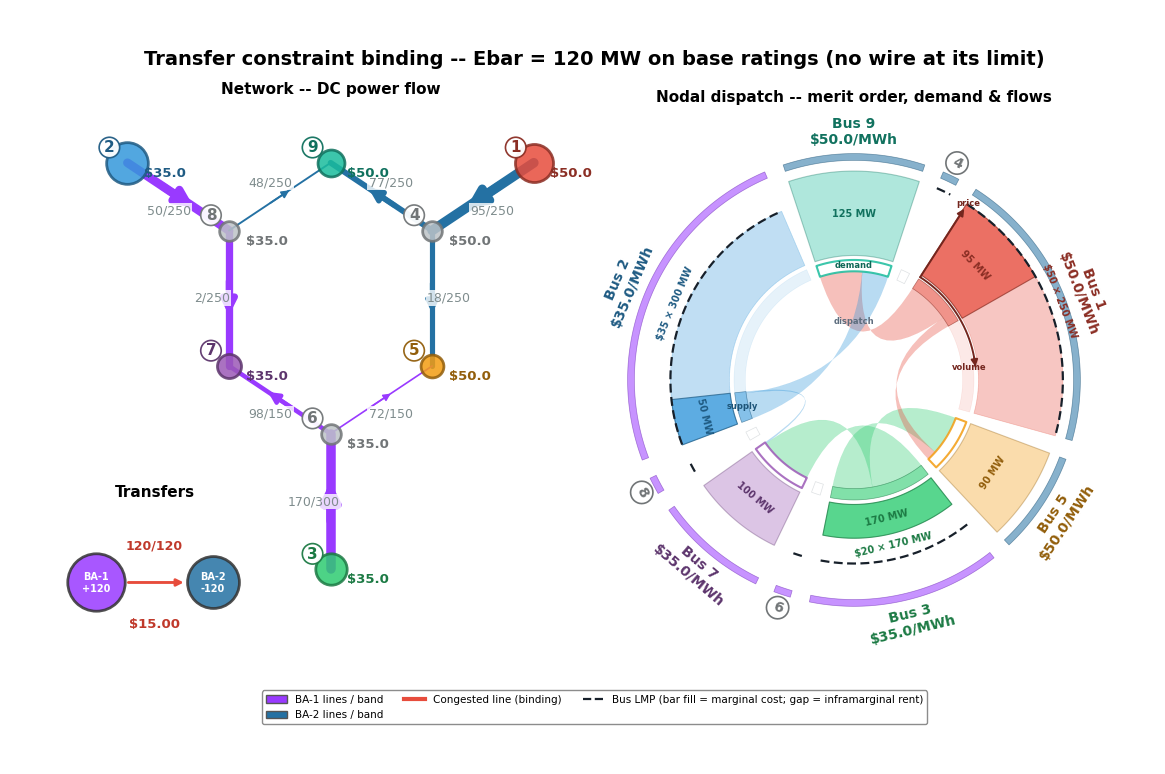

E = 120.0 MW at Ebar = 120  ->  mu_T = -15.00 $/MWh

  BA-1 LMPs:

{'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(35.0), '6': np.float64(35.0), '3': np.float64(35.0)}

  BA-2 LMPs:

{'1': np.float64(50.0), '9': np.float64(50.0), '4': np.float64(50.0), '5': np.float64(50.0)}

...

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines



Ledger -- autarky vs constrained trade; transfer rent by T1 -- fixed shares (TRANSFER_SPLIT)  (congestion Method 1: tau = 0, methods coincide):

BA-1               BA-2              TOTAL
                                           Consumer Generator Consumer Generator         
Autarky: payment / revenue                  -2000.0    2000.0 -10750.0   10750.0      0.0
Autarky: production cost                              -2000.0           -10750.0 -12750.0
Autarky: own congestion rent (CRR)              0.0                0.0                0.0
Autarky: position                           -2000.0       0.0 -10750.0       0.0 -12750.0
Constrained: payment / revenue              -3500.0    7700.0 -10750.0    4750.0  -1800.0
Constrained: production cost                          -5150.0            -4750.0  -9900.0
Congestion rent collected (assigned lines)      0.0                0.0                0.0
Congestion rent allocated (CRR)                 0.0                0.0                0.0
Transfer rent collected (border)                                                   1800.0
Transfer rent allocated (CRR)                 900.0              900.0             1800.0
Final position                              -2600.0    2550.0  -9850.0       0.0  -9900.0
Delta vs autarky                             -600.0    2550.0    900.0       0.0   2850.0
Pareto (Delta >= 0)                              no       yes      yes       yes


Ledger -- autarky vs constrained trade; transfer rent by T2 -- all to the net-payer BA  (congestion Method 1: tau = 0, methods coincide):

BA-1               BA-2              TOTAL
                                           Consumer Generator Consumer Generator         
Autarky: payment / revenue                  -2000.0    2000.0 -10750.0   10750.0      0.0
Autarky: production cost                              -2000.0           -10750.0 -12750.0
Autarky: own congestion rent (CRR)              0.0                0.0                0.0
Autarky: position                           -2000.0       0.0 -10750.0       0.0 -12750.0
Constrained: payment / revenue              -3500.0    7700.0 -10750.0    4750.0  -1800.0
Constrained: production cost                          -5150.0            -4750.0  -9900.0
Congestion rent collected (assigned lines)      0.0                0.0                0.0
Congestion rent allocated (CRR)                 0.0                0.0                0.0
Transfer rent collected (border)                                                   1800.0
Transfer rent allocated (CRR)                   0.0             1800.0             1800.0
Final position                              -3500.0    2550.0  -8950.0       0.0  -9900.0
Delta vs autarky                            -1500.0    2550.0   1800.0       0.0   2850.0
Pareto (Delta >= 0)                              no       yes      yes       yes

In [17]:
# -- EDIT -- bind the border: schedule less than the network wants to move ------
XFER_BIND = 120.0          # Ebar below the ~215 MW unconstrained interchange
# ------------------------------------------------------------------------------
netX, ptX, engX, resX = solve_with_transfer({}, XFER_BIND)
fig = transfer_figure(netX, ptX, engX, resX, XFER_BIND,
                      suptitle=f'Transfer constraint binding -- Ebar = {XFER_BIND:.0f} MW '
                               f'on base ratings (no wire at its limit)')
plt.show()

RT = transfer_rent(resX)
print(f'E = {resX.interchange_mw:.1f} MW at Ebar = {XFER_BIND:.0f}'
      f'  ->  mu_T = {resX.interchange_dual:.2f} $/MWh')
print('  BA-1 LMPs:', {bb: round(resX.lmp[bb], 1) for bb in BA_DEFS['BA-1']})
print('  BA-2 LMPs:', {bb: round(resX.lmp[bb], 1) for bb in BA_DEFS['BA-2']})
print('binding lines:', {l: round(mu, 1) for l, mu in resX.line_dual.items()
                         if abs(mu) > 1e-3} or 'none')

# Tested like the congestion-rent methodology: the settlement wedge must equal R + R_T.
sX = ba_settlement(resX, LOADS_ALL)
wedge = sum(sX[ba]['net_into_pool'] for ba in BA_DEFS)
_, summX, lrX, _ = allocate_congestion_rent(resX, ptX, LOADS_ALL)
print(f'\nconservation:  load pays - gen paid = {wedge:,.1f}   vs   R + R_T = '
      f'{summX["R"]:,.1f} + {RT:,.1f} = {summX["R"] + RT:,.1f}')

print('\ncross-border price-gap decomposition (eq. 9) -- raw gap = line congestion + transfer:')
display(border_separation(resX, ptX)[['flow', 'dlam', 'dlam_cong', 'dlam_xfer', 'sep_rent']].round({'sep_rent': 1}))

# Autarky counterfactual on the SAME (base) ratings -- each BA self-serves.
_, indepX = independent_clear({}, shed_price=SHED_PRICE)

# No line binds, so eq. (9)'s congestion-priced tau is 0 as well as R: the
# congestion methods coincide and the TRANSFER methodology is the only live
# allocation choice -- one ledger per configured transfer rule. Transfer rent
# is COLLECTED at the border (TOTAL column) and ALLOCATED per the rule; the
# autarky block and Pareto row ask who the constrained trade leaves better off.
for _t in TRANSFER_METHODS:
    print(f'\nLedger -- autarky vs constrained trade; transfer rent by {T_NAMES.get(_t, _t)}'
          f'  (congestion Method {CONGESTION_METHODS[0]}: tau = 0, methods coincide):')
    display(transfer_ledger(resX, ptX, LOADS_ALL, CONGESTION_METHODS[0], _t, indepX))


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


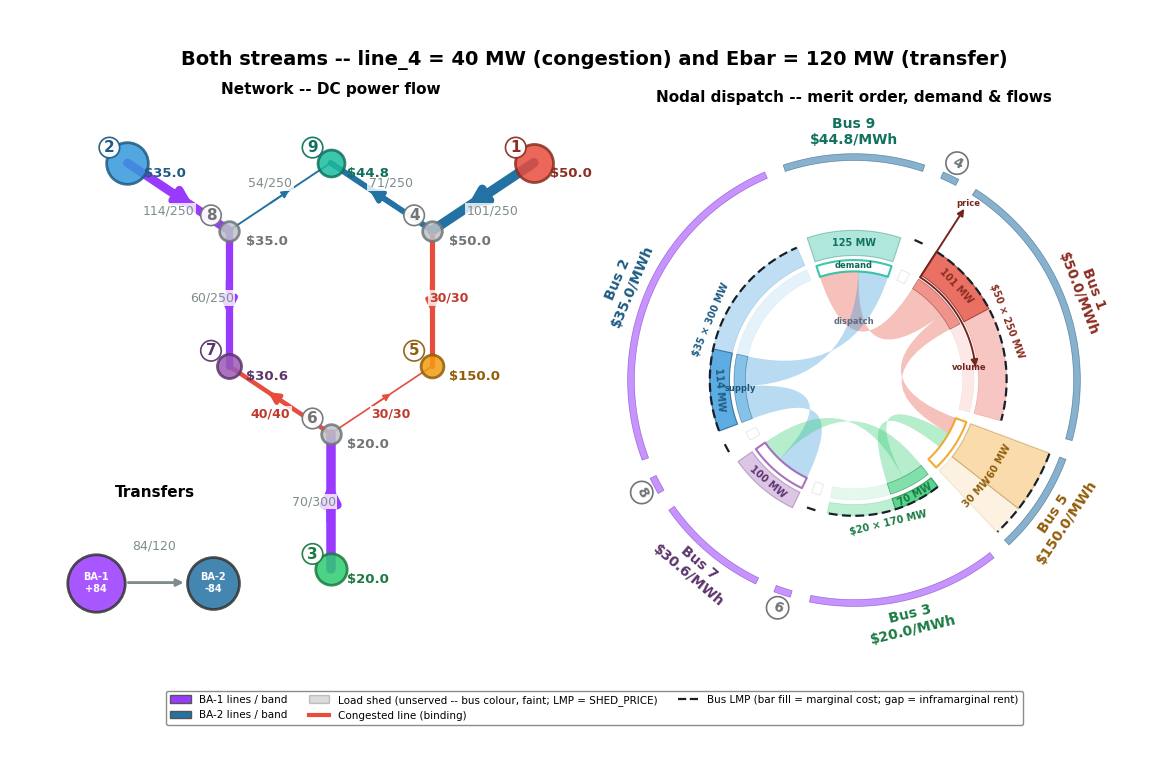

binding lines:

{'line_1': -94.4, 'line_2': 140.4, 'line_4': -4.5}

 |  E = 84 MW,  mu_T = 0.00


per-line congestion rent (binding lines):

,frm,to,kind,home,mu,flow,rent
line,,,,,,,
line_1,4,5,internal,BA-2,-94.39,30.0,2831.7
line_2,5,6,tie,BA-1,140.37,-30.0,4211.0
line_4,6,7,internal,BA-1,-4.46,40.0,178.5


...

BA-1               BA-2              TOTAL
                                           Consumer Generator Consumer Generator         
Autarky: payment / revenue                  -3712.6    2908.5 -10550.9    7082.1  -4272.8
Autarky: production cost                              -2908.5            -7082.1  -9990.6
Autarky: own congestion rent (CRR)            804.1             3468.7             4272.8
Autarky: position                           -2908.5       0.0  -7082.1       0.0  -9990.6
Constrained: payment / revenue              -3061.0    5385.6 -14602.1    5056.3  -7221.2
Constrained: production cost                          -5385.6            -5056.3 -10441.9
Congestion rent collected (assigned lines)   4389.5             2831.7             7221.2
Congestion rent allocated (CRR)              4389.5             2831.7             7221.2
Transfer rent collected (border)                                                      0.0
Transfer rent allocated (CRR)                   0.0                0.0                0.0
Final position                               1328.5       0.0 -11770.4       0.0 -10441.9
Delta vs autarky                             4237.0       0.0  -4688.3       0.0   -451.3
Pareto (Delta >= 0)                             yes       yes       no       yes


Method 2 -- rebate the cross-border separation tau to the net-payer BA;  transfer rent by T1 -- fixed shares (TRANSFER_SPLIT):

BA-1               BA-2              TOTAL
                                           Consumer Generator Consumer Generator         
Autarky: payment / revenue                  -3712.6    2908.5 -10550.9    7082.1  -4272.8
Autarky: production cost                              -2908.5            -7082.1  -9990.6
Autarky: own congestion rent (CRR)            804.1             3468.7             4272.8
Autarky: position                           -2908.5       0.0  -7082.1       0.0  -9990.6
Constrained: payment / revenue              -3061.0    5385.6 -14602.1    5056.3  -7221.2
Constrained: production cost                          -5385.6            -5056.3 -10441.9
Congestion rent collected (assigned lines)   4389.5             2831.7             7221.2
Congestion rent allocated (CRR)               -39.4             7260.6             7221.2
Transfer rent collected (border)                                                      0.0
Transfer rent allocated (CRR)                   0.0                0.0                0.0
Final position                              -3100.3       0.0  -7341.5       0.0 -10441.9
Delta vs autarky                             -191.8       0.0   -259.4       0.0   -451.3
Pareto (Delta >= 0)                              no       yes       no       yes


Method 2 -- rebate the cross-border separation tau to the net-payer BA;  transfer rent by T2 -- all to the net-payer BA:

BA-1               BA-2              TOTAL
                                           Consumer Generator Consumer Generator         
Autarky: payment / revenue                  -3712.6    2908.5 -10550.9    7082.1  -4272.8
Autarky: production cost                              -2908.5            -7082.1  -9990.6
Autarky: own congestion rent (CRR)            804.1             3468.7             4272.8
Autarky: position                           -2908.5       0.0  -7082.1       0.0  -9990.6
Constrained: payment / revenue              -3061.0    5385.6 -14602.1    5056.3  -7221.2
Constrained: production cost                          -5385.6            -5056.3 -10441.9
Congestion rent collected (assigned lines)   4389.5             2831.7             7221.2
Congestion rent allocated (CRR)               -39.4             7260.6             7221.2
Transfer rent collected (border)                                                      0.0
Transfer rent allocated (CRR)                   0.0                0.0                0.0
Final position                              -3100.3       0.0  -7341.5       0.0 -10441.9
Delta vs autarky                             -191.8       0.0   -259.4       0.0   -451.3
Pareto (Delta >= 0)                              no       yes       no       yes

In [18]:
# Both revenue streams at once: the Section-2 internal limit AND the binding border.
# line_4 (6-7, internal to BA-1) at 40 MW collects congestion rent on BA-1's
# wires; the schedule at Ebar = XFER_BIND collects transfer rent on the border.
netC, ptC, engC, resC = solve_with_transfer(dict(LINE_RATINGS), XFER_BIND)
fig = transfer_figure(netC, ptC, engC, resC, XFER_BIND,
                      suptitle=f'Both streams -- line_4 = {LINE_RATINGS["line_4"]:.0f} MW '
                               f'(congestion) and Ebar = {XFER_BIND:.0f} MW (transfer)')
plt.show()

RTC = transfer_rent(resC)
allocC, summC, lrC, sepC = allocate_congestion_rent(resC, ptC, LOADS_ALL)
print('binding lines:', {l: round(mu, 1) for l, mu in resC.line_dual.items()
                         if abs(mu) > 1e-3},
      f' |  E = {resC.interchange_mw:.0f} MW,  mu_T = {resC.interchange_dual:.2f}')
print('\nper-line congestion rent (binding lines):')
display(lrC[lrC.rent > 1e-3].round({'rent': 1}))

print('cross-border price-gap decomposition (eq. 9) -- raw gap = line congestion + transfer;')
print('Method 2 moves only the congestion part (tau), the transfer part is settled as R_T:')
display(sepC[['flow', 'dlam', 'dlam_cong', 'dlam_xfer', 'sep_rent']].round({'sep_rent': 1}))

sC = ba_settlement(resC, LOADS_ALL)
wedgeC = sum(sC[ba]['net_into_pool'] for ba in BA_DEFS)
print(f'conservation:  load pays - gen paid = {wedgeC:,.1f}   vs   R + R_T = '
      f'{summC["R"]:,.1f} + {RTC:,.1f} = {summC["R"] + RTC:,.1f}')

# Autarky counterfactual on the SAME ratings (line_4 = 40, the Section-3 one).
_, indepC = independent_clear(dict(LINE_RATINGS), shed_price=SHED_PRICE)
_M_NAMES = {1: 'Method 1 -- congestion rent stays with the managing BA',
            2: 'Method 2 -- rebate the cross-border separation tau to the net-payer BA'}
# One ledger per configured (congestion, transfer) methodology pair -- trim
# either list in the EDIT cell to show fewer tables. Only the two allocated
# rows move between tables; collected rows and every total are invariant.
for _m in CONGESTION_METHODS:
    for _t in TRANSFER_METHODS:
        print('\n' + _M_NAMES.get(_m, f'Method {_m}')
              + f';  transfer rent by {T_NAMES.get(_t, _t)}:')
        display(transfer_ledger(resC, ptC, LOADS_ALL, _m, _t, indepC))


**Read it.** With only the border constrained (middle example) prices are flat
within each BA — two energy prices linked by a constrained schedule, EDAM's
per-BAA structure in miniature — and the whole settlement wedge is transfer
rent, $R_T=|\mu_T E|$, split by the configured shares. With `line_4` back at 40 MW (last example)
the **two revenue streams coexist**: BA-1's internal wire collects congestion
rent $R$ exactly as in Section 3, the border schedule collects $R_T$ on top, and
the wedge is their sum — the conservation line checks it to the cent. Note the
interplay: with the internal limit in place $|\mu_T|$ is *larger* than in the
pure-border case, because the redispatch the schedule forces interacts with the
congested wire.

The middle example is also where eq. (9)'s constraint-based $\tau$ earns its
keep. The raw price gap across each tie is $|\mu_T|$ — but no **line** is binding,
so the congestion component of that gap is zero, $\tau=0$, and Methods 1 and 2
genuinely coincide: the border's separation is settled once, as $R_T$, not a second
time through a rebate. In the combined example the decomposition table makes the
same point line by line: each tie's raw gap splits into a line-congestion part
(`dlam_cong`, the only piece $\tau$ prices and Method 2 moves) and a transfer part
(`dlam_xfer` $=\pm\mu_T$, settled as $R_T$ by the configured transfer rule) — every dollar of separation
settled exactly once, by the constraint that created it.

The autarky block prices the distributional story. Constrained trade still
beats autarky in total — the TOTAL of the *Delta vs autarky* row is exactly the
production-cost saving — but the gains need not reach everyone. In the middle
example BA-1's **consumers** end up *worse* than autarky (the export pulls
their cheap unit away and their price rises from \$20 toward the importer's
\$50) even as BA-1's **generators** gain several times that: the border fails the
Pareto check on one column. With `line_4` back at 40 MW the autarky baseline is
itself expensive enough that every column clears the check under the default
50/50 — but the methodology grid has corners: stack **both** rebates on the
net-payer (Method 2 x T2) and the exporter's consumers drop below autarky
again, while Method 1 x T2 leaves them exactly at their autarky position. How much of each rent is
rebated to whom — `CONGESTION_METHODS`, `TRANSFER_METHODS` — is what decides
whether integrating across the border is merely efficient or actually Pareto-improving:
switching the transfer rule from T1 to T2 moves the whole rebate to the
importer and *deepens* the exporter-consumer loss — the methodology choice is
pure distribution, the production-cost saving never moves.

